# Эмбеддинг Analysis

Этот ноутбук добавляет центральный для курсовой этап: анализ пользовательских эмбеддингов, полученных из `GRU` и `LSTM` энкодеров.

В предыдущих ноутбуках были подготовлены данные, обучены рекуррентные модели и проверена downstream-полезность эмбеддингов. Здесь фокус другой: понять, какие представления пользователей построились, не схлопнулись ли они, связаны ли они с активностью и можно ли интерпретировать группы пользователей в пространстве эмбеддингов.

## План

1. Загрузить `GRU` и `LSTM`-эмбеддинги, split и поведенческую metadata.
2. Проверить базовую диагностику пространства эмбеддингов: размерности, нормы, PCA explained variance.
3. Визуализировать 2D-проекции эмбеддингов и связать их с активностью и retention.
4. Построить кластеры пользователей по `GRU`-эмбеддингам и описать их через поведенческие признаки.
5. Сохранить таблицы и графики, которые можно использовать в отчёте и финальном сравнении с `SimCLR` / `BERT4Rec`.

In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault('LOKY_MAX_CPU_COUNT', '8')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path('/Users/fedornikonov/hse_recsys_rnn')
sys.path.append(str(PROJECT_ROOT))

from src.embedding_analysis import (
    add_embedding_norm,
    build_activity_bucket,
    cluster_profile,
    embedding_columns,
    embedding_matrix,
    fit_kmeans,
    pca_projection,
)

ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts/embedding_analysis'
FIGURES_DIR = ARTIFACTS_DIR / 'figures'
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', context='notebook')

def to_pandas(df: pl.DataFrame) -> pd.DataFrame:
    return pd.DataFrame(df.to_dicts())
RANDOM_STATE = 42
SAMPLE_SIZE = 10_000

## 1. Загрузка артефактов

Используются уже построенные full-history эмбеддинги из `02_rnn_baseline.ipynb`. Эти эмбеддинги строятся по последней части полной пользовательской истории, поэтому ноутбук анализирует полный поведенческий профиль, а не проверяет ранний downstream-прогноз без утечки будущих событий. Для интерпретации к ним добавляются длина последовательности, split и prefix-based признаки/метки из downstream-этапа. Здесь downstream-таблица не становится основной задачей: она используется как metadata для понимания того, что кодируется в эмбеддингах.

In [2]:
gru_embeddings = pl.read_parquet(PROJECT_ROOT / 'artifacts/rnn/user_embeddings.parquet')
lstm_embeddings = pl.read_parquet(PROJECT_ROOT / 'artifacts/rnn/user_embeddings_lstm.parquet')
sequences = pl.read_parquet(PROJECT_ROOT / 'artifacts/data/user_sequences.parquet')
split_users = pl.read_parquet(PROJECT_ROOT / 'artifacts/data/split_users.parquet')
downstream_meta = pl.read_parquet(PROJECT_ROOT / 'artifacts/downstream/downstream_table.parquet').select(
    [
        'appmetrica_device_id',
        'prefix_len_feature',
        'unique_event_count',
        'repeat_ratio',
        'prefix_session_count',
        'prefix_active_days',
        'retention_7d',
        'retention_14d',
    ]
)

metadata = (
    sequences.select(['appmetrica_device_id', 'sequence_len'])
    .join(split_users, on='appmetrica_device_id', how='left')
    .join(downstream_meta, on='appmetrica_device_id', how='left')
)
metadata = build_activity_bucket(metadata)

gru_cols = embedding_columns(gru_embeddings.columns)
lstm_cols = embedding_columns(lstm_embeddings.columns)

shape_summary = pl.DataFrame(
    {
        'artifact': ['GRU embeddings', 'LSTM embeddings', 'metadata'],
        'num_users': [gru_embeddings.height, lstm_embeddings.height, metadata.height],
        'num_columns': [gru_embeddings.width, lstm_embeddings.width, metadata.width],
        'embedding_dim': [len(gru_cols), len(lstm_cols), None],
    }
)
shape_summary

artifact,num_users,num_columns,embedding_dim
str,i64,i64,i64
"""GRU embeddings""",52495,129,128
"""LSTM embeddings""",52495,129,128
"""metadata""",52495,11,null


Проверка размерностей нужна как sanity check: дальше все сравнения должны строиться на одинаковом наборе пользователей и фиксированном `appmetrica_device_id`.

In [3]:
coverage_summary = (
    metadata.select([
        pl.len().alias('num_users'),
        pl.col('split').null_count().alias('missing_split'),
        pl.col('retention_7d').null_count().alias('missing_retention_7d'),
        pl.col('retention_14d').null_count().alias('missing_retention_14d'),
        pl.col('sequence_len').min().alias('min_sequence_len'),
        pl.col('sequence_len').median().alias('median_sequence_len'),
        pl.col('sequence_len').quantile(0.90).alias('p90_sequence_len'),
        pl.col('sequence_len').quantile(0.99).alias('p99_sequence_len'),
        pl.col('sequence_len').max().alias('max_sequence_len'),
    ])
)
coverage_summary

num_users,missing_split,missing_retention_7d,missing_retention_14d,min_sequence_len,median_sequence_len,p90_sequence_len,p99_sequence_len,max_sequence_len
u32,u32,u32,u32,i64,f64,f64,f64,i64
52495,0,33948,37288,10,83.0,2400.0,14485.0,185204


## 2. Базовая диагностика эмбеддингов

На этом шаге проверяется, что эмбеддинги не схлопнулись и имеют измеримую структуру. Для этого используются две проверки: распределение `L2`-норм и PCA explained variance. Эти проверки не являются финальной метрикой качества, но позволяют понять, есть ли у полученного пространства эмбеддингов содержательная геометрия.


In [4]:
gru_with_norm = add_embedding_norm(gru_embeddings, gru_cols).join(metadata, on='appmetrica_device_id', how='left')
lstm_with_norm = add_embedding_norm(lstm_embeddings, lstm_cols).join(metadata, on='appmetrica_device_id', how='left')

norm_summary = pl.concat(
    [
        gru_with_norm.select(
            pl.lit('GRU').alias('model'),
            pl.col('embedding_norm').mean().alias('mean_norm'),
            pl.col('embedding_norm').std().alias('std_norm'),
            pl.col('embedding_norm').quantile(0.01).alias('p01_norm'),
            pl.col('embedding_norm').median().alias('median_norm'),
            pl.col('embedding_norm').quantile(0.99).alias('p99_norm'),
        ),
        lstm_with_norm.select(
            pl.lit('LSTM').alias('model'),
            pl.col('embedding_norm').mean().alias('mean_norm'),
            pl.col('embedding_norm').std().alias('std_norm'),
            pl.col('embedding_norm').quantile(0.01).alias('p01_norm'),
            pl.col('embedding_norm').median().alias('median_norm'),
            pl.col('embedding_norm').quantile(0.99).alias('p99_norm'),
        ),
    ]
)
norm_summary.write_csv(ARTIFACTS_DIR / 'norm_summary.csv')
norm_summary

model,mean_norm,std_norm,p01_norm,median_norm,p99_norm
str,f64,f64,f64,f64,f64
"""GRU""",8.443968,0.374033,7.544257,8.433606,9.181527
"""LSTM""",6.95371,0.479089,5.822431,7.039219,7.738588


Вывод.

По таблице видно, что `GRU`-эмбеддинги имеют среднюю норму `8.44`, а `LSTM` — `6.95`. При этом разброс умеренный: для `GRU` интервал `p01-p99` составляет примерно `7.54-9.18`, для `LSTM` — `5.82-7.74`. Это хороший sanity check: эмбеддинги не схлопнулись в нули и не выглядят как пространство, где несколько пользователей создают экстремальные выбросы.


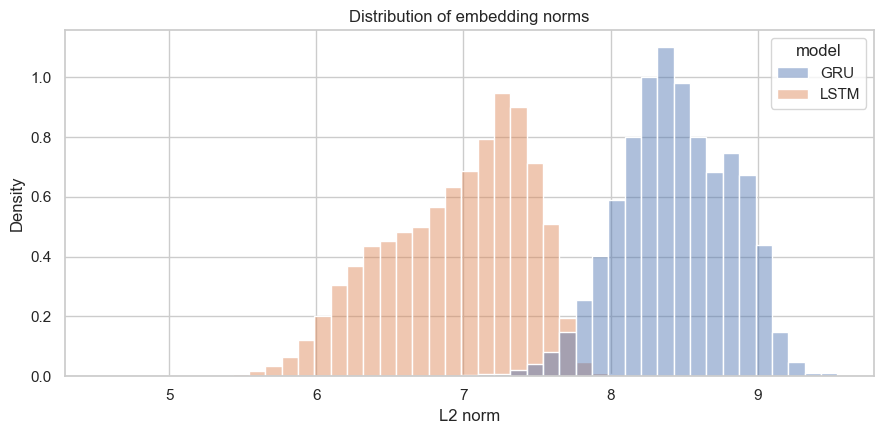

In [5]:
norm_plot_df = to_pandas(
    pl.concat(
        [
            gru_with_norm.select(['appmetrica_device_id', 'embedding_norm']).with_columns(pl.lit('GRU').alias('model')),
            lstm_with_norm.select(['appmetrica_device_id', 'embedding_norm']).with_columns(pl.lit('LSTM').alias('model')),
        ]
    )
)

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(data=norm_plot_df, x='embedding_norm', hue='model', bins=45, stat='density', common_norm=False, alpha=0.45, ax=ax)
ax.set_title('Distribution of embedding norms')
ax.set_xlabel('L2 norm')
ax.set_ylabel('Density')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'embedding_norms.png', dpi=180)
plt.show()

In [6]:
sample_user_ids = metadata.sample(n=min(SAMPLE_SIZE, metadata.height), seed=RANDOM_STATE).select('appmetrica_device_id')
gru_sample = sample_user_ids.join(gru_with_norm, on='appmetrica_device_id', how='left')
lstm_sample = sample_user_ids.join(lstm_with_norm, on='appmetrica_device_id', how='left')

gru_pca, gru_pca_var = pca_projection(gru_sample, gru_cols, n_components=10, seed=RANDOM_STATE)
lstm_pca, lstm_pca_var = pca_projection(lstm_sample, lstm_cols, n_components=10, seed=RANDOM_STATE)

pca_variance = pl.DataFrame(
    {
        'component': list(range(1, 11)) * 2,
        'model': ['GRU'] * 10 + ['LSTM'] * 10,
        'explained_variance_ratio': np.concatenate([gru_pca_var, lstm_pca_var]),
        'cumulative_explained_variance': np.concatenate([np.cumsum(gru_pca_var), np.cumsum(lstm_pca_var)]),
    }
)
pca_variance.write_csv(ARTIFACTS_DIR / 'pca_variance.csv')
pca_variance

component,model,explained_variance_ratio,cumulative_explained_variance
i64,str,f64,f64
1,"""GRU""",0.181877,0.181877
2,"""GRU""",0.104117,0.285994
3,"""GRU""",0.081837,0.36783
4,"""GRU""",0.058066,0.425896
5,"""GRU""",0.045291,0.471187
…,…,…,…
6,"""LSTM""",0.030016,0.471879
7,"""LSTM""",0.028271,0.50015
8,"""LSTM""",0.027686,0.527836


Вывод.

Первые 10 PCA-компонент объясняют `60.5%` дисперсии у `GRU` и `57.8%` у `LSTM`. Значит, структура эмбеддингов достаточно концентрирована: существенная часть различий между пользователями описывается небольшим числом направлений. Это удобно для интерпретации и последующего сравнения с `SimCLR` и `BERT4Rec`.


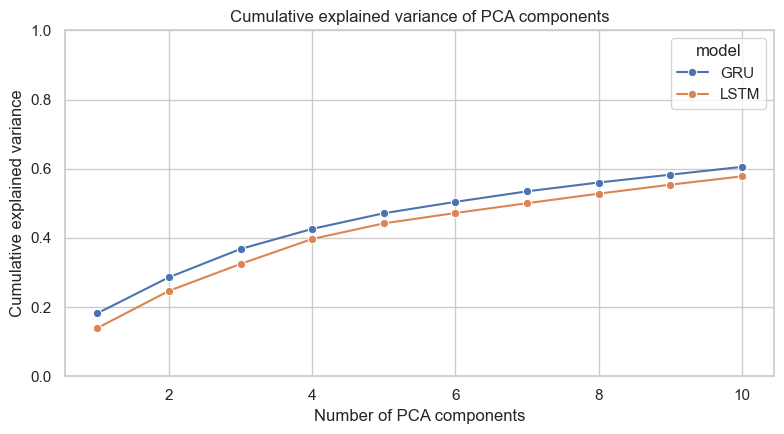

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.lineplot(data=to_pandas(pca_variance), x='component', y='cumulative_explained_variance', hue='model', marker='o', ax=ax)
ax.set_title('Cumulative explained variance of PCA components')
ax.set_xlabel('Number of PCA components')
ax.set_ylabel('Cumulative explained variance')
ax.set_ylim(0, 1)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'pca_cumulative_variance.png', dpi=180)
plt.show()

## 3. 2D-проекции пространства эмбеддингов

PCA-проекция используется как диагностическая визуализация. Важно не то, что двумерная картинка сама по себе доказывает качество модели, а то, совпадают ли направления в пространстве эмбеддингов с признаками, которые не использовались при обучении RNN напрямую: длиной истории, активностью и retention labels.


In [8]:
gru_projection_2d, gru_projection_var = pca_projection(gru_sample, gru_cols, n_components=2, seed=RANDOM_STATE)
gru_projection_2d = gru_projection_2d.join(metadata, on='appmetrica_device_id', how='left')
gru_projection_2d.write_parquet(ARTIFACTS_DIR / 'gru_pca_projection_sample.parquet')

gru_projection_var

array([0.18187726, 0.10411658])

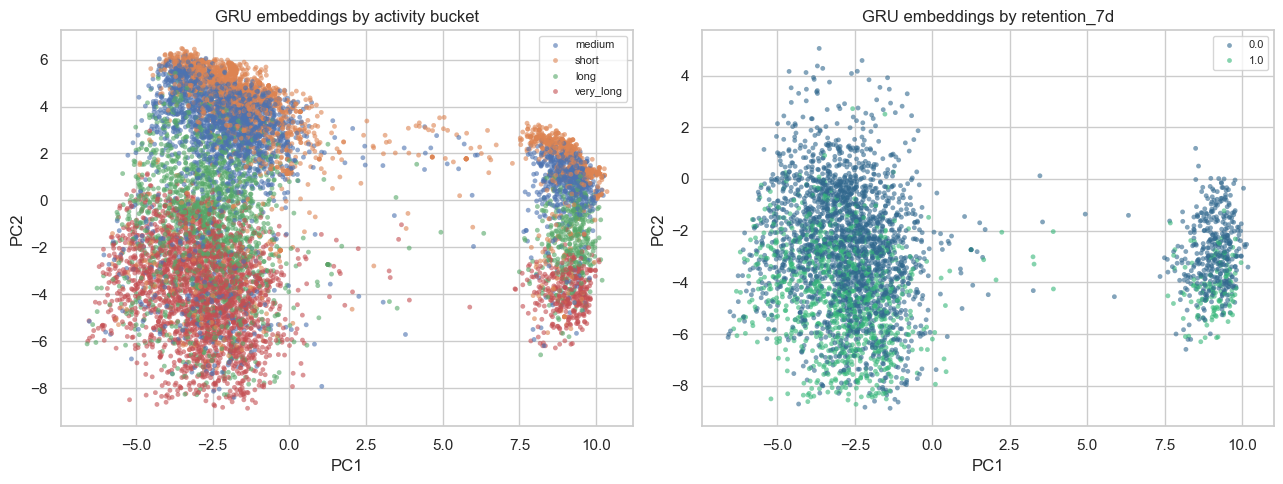

In [9]:
plot_df = to_pandas(gru_projection_2d)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(
    data=plot_df,
    x='pc_1',
    y='pc_2',
    hue='activity_bucket',
    s=12,
    alpha=0.6,
    linewidth=0,
    ax=axes[0],
)
axes[0].set_title('GRU embeddings by activity bucket')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

sns.scatterplot(
    data=plot_df,
    x='pc_1',
    y='pc_2',
    hue='retention_7d',
    palette='viridis',
    s=12,
    alpha=0.6,
    linewidth=0,
    ax=axes[1],
)
axes[1].set_title('GRU embeddings by retention_7d')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

for ax in axes:
    ax.legend(loc='best', fontsize=8, frameon=True)

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'gru_pca_activity_retention.png', dpi=180)
plt.show()

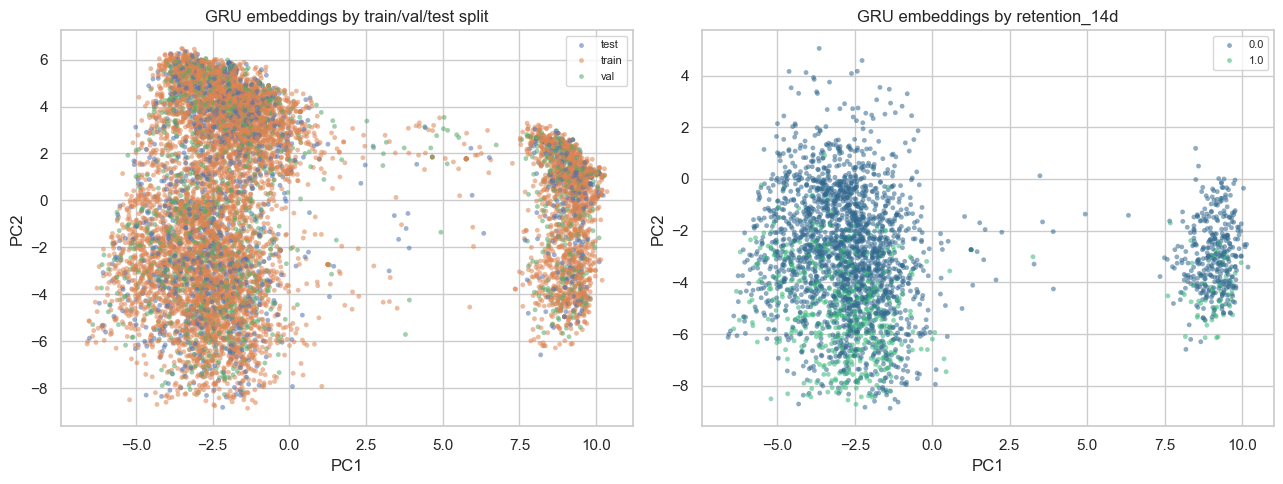

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(
    data=plot_df,
    x='pc_1',
    y='pc_2',
    hue='split',
    s=12,
    alpha=0.55,
    linewidth=0,
    ax=axes[0],
)
axes[0].set_title('GRU embeddings by train/val/test split')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

sns.scatterplot(
    data=plot_df,
    x='pc_1',
    y='pc_2',
    hue='retention_14d',
    palette='viridis',
    s=12,
    alpha=0.55,
    linewidth=0,
    ax=axes[1],
)
axes[1].set_title('GRU embeddings by retention_14d')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

for ax in axes:
    ax.legend(loc='best', fontsize=8, frameon=True)

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'gru_pca_split_retention14.png', dpi=180)
plt.show()

Вывод.

PCA-проекция используется как sanity check, а не как финальная метрика качества. Train, val и test визуально хорошо перемешаны, поэтому явного distribution shift между частями split не видно. При раскраске по activity_bucket появляется устойчивый градиент: пользователи с более длинной и активной историей смещаются в отдельные области пространства.

Для retention_7d и retention_14d классы не разделяются полностью, но положительный retention концентрируется в некоторых областях проекции. Это подтверждает, что GRU-эмбеддинги содержат retention-сигнал, однако задача не является тривиально разделимой в 2D; финальное качество поэтому оценивается downstream-моделью и ROC-AUC/PR-AUC, а не только визуализацией.


## 4. Кластеризация пользователей по эмбеддингам

Кластеризация используется как интерпретация пространства эмбеддингов. Если группы, найденные только по `GRU`-векторам, заметно отличаются по sequence length, repeat ratio и retention, значит энкодер перенёс в эмбеддинги поведенческую информацию, а не только выучил техническое представление для next-event prediction.


In [11]:
kmeans_input = gru_embeddings.join(metadata, on='appmetrica_device_id', how='left')
kmeans_sample = kmeans_input.sample(n=min(SAMPLE_SIZE, kmeans_input.height), seed=RANDOM_STATE)
X_sample = embedding_matrix(kmeans_sample, gru_cols, standardize=True)

k_scores = []
for k in range(3, 9):
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = model.fit_predict(X_sample)
    sil = silhouette_score(X_sample, labels, sample_size=min(10_000, len(labels)), random_state=RANDOM_STATE)
    k_scores.append({'k': k, 'inertia': float(model.inertia_), 'silhouette': float(sil)})

kmeans_scores = pl.DataFrame(k_scores)
kmeans_scores.write_csv(ARTIFACTS_DIR / 'kmeans_scores.csv')
kmeans_scores

k,inertia,silhouette
i64,f64,f64
3,961245.943018,0.173746
4,904738.235721,0.170617
5,863820.706682,0.170703
6,828339.606314,0.151071
7,792732.154523,0.166518
8,768409.267881,0.174751


Вывод.

Silhouette score невысокий для всех `k` (`0.15-0.17`), поэтому кластеры нельзя трактовать как идеально разделённые классы пользователей. Но для исследовательской интерпретации этого достаточно: `k=5` даёт читаемый компромисс между детализацией и простотой объяснения, а дальнейшее увеличение `k` не даёт очевидного качественного скачка.


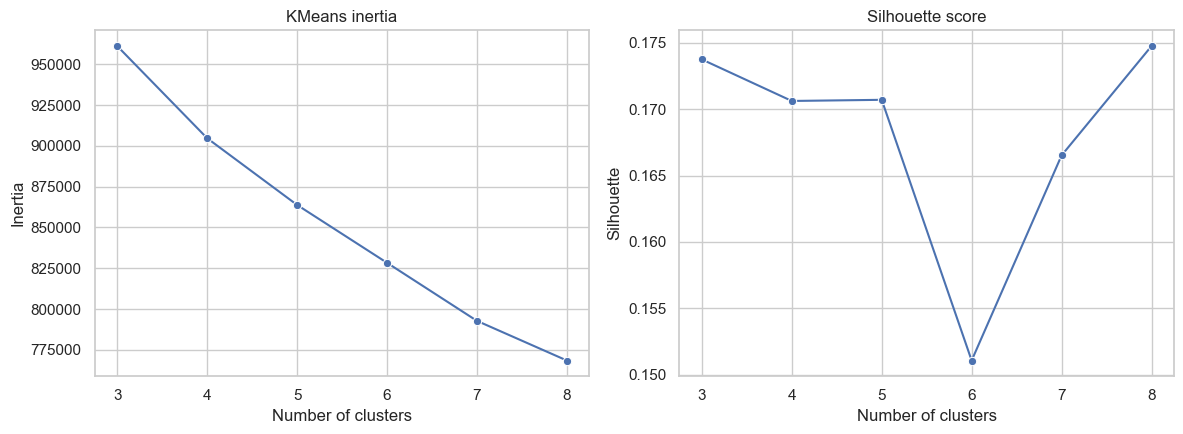

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
score_df = to_pandas(kmeans_scores)

sns.lineplot(data=score_df, x='k', y='inertia', marker='o', ax=axes[0])
axes[0].set_title('KMeans inertia')
axes[0].set_xlabel('Number of clusters')
axes[0].set_ylabel('Inertia')

sns.lineplot(data=score_df, x='k', y='silhouette', marker='o', ax=axes[1])
axes[1].set_title('Silhouette score')
axes[1].set_xlabel('Number of clusters')
axes[1].set_ylabel('Silhouette')

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'kmeans_k_selection.png', dpi=180)
plt.show()

Для интерпретации фиксируется умеренное число кластеров. Здесь важна не максимизация одной метрики, а читаемость групп: слишком много кластеров усложняет объяснение в отчёте, слишком мало скрывает различия между типами пользователей.

In [13]:
N_CLUSTERS = 5
assignments, inertia, silhouette = fit_kmeans(gru_embeddings, gru_cols, n_clusters=N_CLUSTERS, seed=RANDOM_STATE)
profile = cluster_profile(assignments, metadata)

assignments.write_parquet(ARTIFACTS_DIR / 'gru_kmeans_assignments.parquet')
profile.write_csv(ARTIFACTS_DIR / 'gru_kmeans_profile.csv')

pl.DataFrame({'n_clusters': [N_CLUSTERS], 'inertia': [inertia], 'silhouette': [silhouette]})

n_clusters,inertia,silhouette
i64,f64,f64
5,4.5452e6,0.168171


Вывод.

Профили показывают сильную связь между пространством `GRU`-эмбеддингов и активностью пользователя. Кластер `1` содержит самую короткую группу: `16 533` пользователя, median sequence length `28`, retention_7d около `4.1%`. Активные кластеры `2`, `3`, `4` имеют median sequence length `393-526` и retention_7d около `27-31%`. Так как кластеры строились только по эмбеддингам, это означает, что RNN-вектора действительно кодируют поведенческую интенсивность и связанную с ней вероятность возврата.


In [14]:
profile

cluster,num_users,median_sequence_len,mean_sequence_len,mean_unique_events,mean_repeat_ratio,mean_prefix_active_days,retention_7d_rate,retention_14d_rate
i32,u32,f64,f64,f64,f64,f64,f64,f64
1,16533,28.0,41.406762,7.043005,0.723771,1.13095,0.040541,0.02924
0,10982,39.0,555.600801,7.943908,0.752026,1.187762,0.224629,0.130964
4,8509,393.0,1618.449407,9.285815,0.908637,1.29792,0.27262,0.178003
2,8331,526.0,1975.026407,9.761613,0.912468,1.334534,0.307933,0.208473
3,8140,477.0,1722.359828,9.275184,0.906417,1.351106,0.300308,0.189


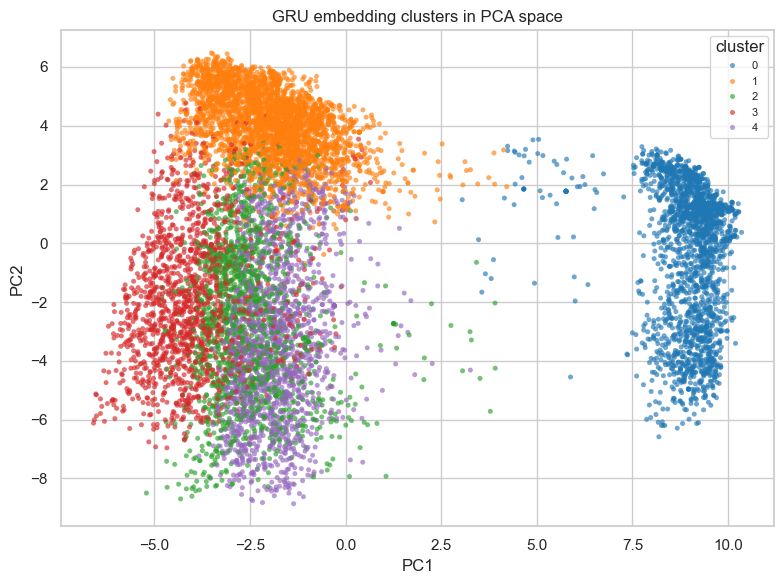

In [15]:
cluster_projection = gru_projection_2d.join(assignments, on='appmetrica_device_id', how='left')
cluster_plot_df = to_pandas(cluster_projection)

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=cluster_plot_df,
    x='pc_1',
    y='pc_2',
    hue='cluster',
    palette='tab10',
    s=13,
    alpha=0.65,
    linewidth=0,
    ax=ax,
)
ax.set_title('GRU embedding clusters in PCA space')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend(title='cluster', loc='best', fontsize=8, frameon=True)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'gru_clusters_pca.png', dpi=180)
plt.show()

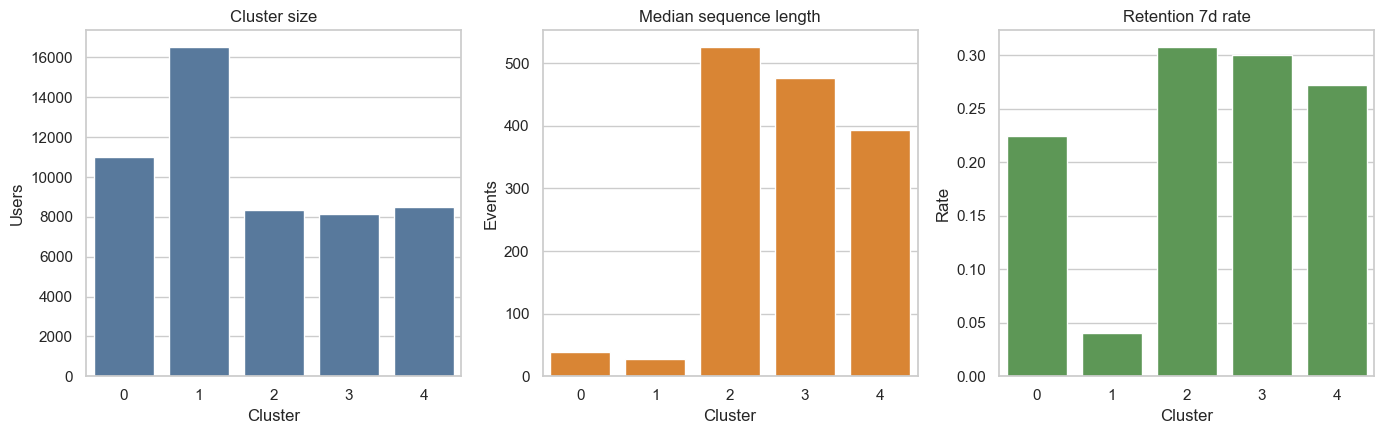

In [16]:
profile_plot = to_pandas(profile.sort('cluster'))
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

sns.barplot(data=profile_plot, x='cluster', y='num_users', ax=axes[0], color='#4C78A8')
axes[0].set_title('Cluster size')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Users')

sns.barplot(data=profile_plot, x='cluster', y='median_sequence_len', ax=axes[1], color='#F58518')
axes[1].set_title('Median sequence length')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Events')

sns.barplot(data=profile_plot, x='cluster', y='retention_7d_rate', ax=axes[2], color='#54A24B')
axes[2].set_title('Retention 7d rate')
axes[2].set_xlabel('Cluster')
axes[2].set_ylabel('Rate')

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'gru_cluster_profiles.png', dpi=180)
plt.show()

## 5. GRU и LSTM как энкодеры эмбеддингов

В `02_rnn_baseline.ipynb` `LSTM` почти не улучшила метрики последовательностной задачи относительно `GRU`. Здесь это дополнительно проверяется на уровне полученных пространств эмбеддингов: сравниваются нормы, PCA-структура и близость пользователей внутри каждого пространства. Так как `GRU` и `LSTM` обучаются независимо, прямое покоординатное сравнение векторов не интерпретируется как качество; важнее сравнивать структуру и переносимость в downstream evaluation.

In [17]:
def mean_neighbor_similarity(df: pl.DataFrame, embedding_cols: list[str], sample_size: int = 3000) -> float:
    sample = df.sample(n=min(sample_size, df.height), seed=RANDOM_STATE)
    matrix = embedding_matrix(sample, embedding_cols, standardize=True)
    sims = cosine_similarity(matrix)
    np.fill_diagonal(sims, np.nan)
    nearest = np.nanmax(sims, axis=1)
    return float(np.mean(nearest))

space_summary = norm_summary.join(
    pca_variance.filter(pl.col('component') == 10).select(
        ['model', pl.col('cumulative_explained_variance').alias('pca10_cumulative_variance')]
    ),
    on='model',
    how='left',
).with_columns(
    pl.Series('mean_nearest_neighbor_cosine_sample', [
        mean_neighbor_similarity(gru_embeddings, gru_cols),
        mean_neighbor_similarity(lstm_embeddings, lstm_cols),
    ])
)
space_summary.write_csv(ARTIFACTS_DIR / 'embedding_space_summary.csv')
space_summary

model,mean_norm,std_norm,p01_norm,median_norm,p99_norm,pca10_cumulative_variance,mean_nearest_neighbor_cosine_sample
str,f64,f64,f64,f64,f64,f64,f64
"""GRU""",8.443968,0.374033,7.544257,8.433606,9.181527,0.605256,0.888963
"""LSTM""",6.95371,0.479089,5.822431,7.039219,7.738588,0.577883,0.888896


Вывод.

`GRU` и `LSTM` дают близкие пространства эмбеддингов: top-10 PCA variance `0.605` против `0.578`, средняя nearest-neighbor cosine similarity `0.889` против `0.889`. Это согласуется с sequence-экспериментом: на `test` `LSTM` почти не отличается от `GRU` по `MRR` (`0.8886` против `0.8885`) и `Hit@10` (`0.9927` против `0.9926`). Поэтому в качестве основного RNN-энкодера рационально оставить более простой `GRU`.


## Итог

Анализ full-history эмбеддингов показывает, что `GRU` и `LSTM` формируют не вырожденные и содержательно структурированные пользовательские представления.

Основные экспериментальные выводы:

- `GRU` и `LSTM`-эмбеддинги имеют разные, но стабильные масштабы: средняя `L2`-норма равна `8.44` для `GRU` и `6.95` для `LSTM`; интервалы `p01-p99` составляют примерно `7.54-9.18` и `5.82-7.74`.
- Первые 10 PCA-компонент объясняют `60.5%` дисперсии для `GRU` и `57.8%` для `LSTM`, то есть пространство имеет выраженную низкоразмерную структуру.
- Ближайшие соседи в стандартизованном пространстве эмбеддингов имеют близкую среднюю cosine similarity: `0.889` для `GRU` и `0.889` для `LSTM`. Это согласуется с sequence-результатами, где `GRU` и `LSTM` почти равны.
- Кластеры по full-history `GRU`-эмбеддинги хорошо разделяют пользователей по активности: короткий кластер содержит `16 533` пользователя с median sequence length `28`, а активные кластеры имеют median sequence length `393-526`.

Важно: этот ноутбук анализирует full-history эмбеддинги, построенные по последней части полной истории пользователя. Поэтому retention здесь используется только как metadata для интерпретации структуры пространства, а строгая downstream-проверка без утечки будущих событий находится в prefix-based ноутбуках `03` и `05`.

Практический вывод: `GRU` уже даёт интерпретируемое пространство пользователей, а дальнейшее улучшение стоит искать не столько в замене `GRU` на `LSTM`, сколько в способе извлечения user embedding из скрытых состояний и в общем сравнении с `SimCLR` / `BERT4Rec`.
